## Bộ dữ liệu được sử dụng trong nghiên cứu này là Pima Indians Diabetes Dataset, chứa các thông tin lâm sàng của phụ nữ gốc Pima (Mỹ) với 8 đặc trưng chính liên quan đến sức khỏe như:

- Pregnancies – số lần mang thai

- Glucose – nồng độ glucose trong máu

- BloodPressure – huyết áp tâm trương

- SkinThickness – độ dày lớp da (mm)

- Insulin – nồng độ insulin huyết thanh

- BMI – chỉ số khối cơ thể

- DiabetesPedigreeFunction – chỉ số di truyền về nguy cơ tiểu đường

- Age – tuổi của bệnh nhân

- Cột Outcome (0 = không bị tiểu đường, 1 = bị tiểu đường) là nhãn mục tiêu.
Mục tiêu của bài toán là xây dựng mô hình dự đoán khả năng mắc bệnh đái tháo đường dựa trên các đặc trưng nêu trên.

# Exploratory Data Analysis (EDA)

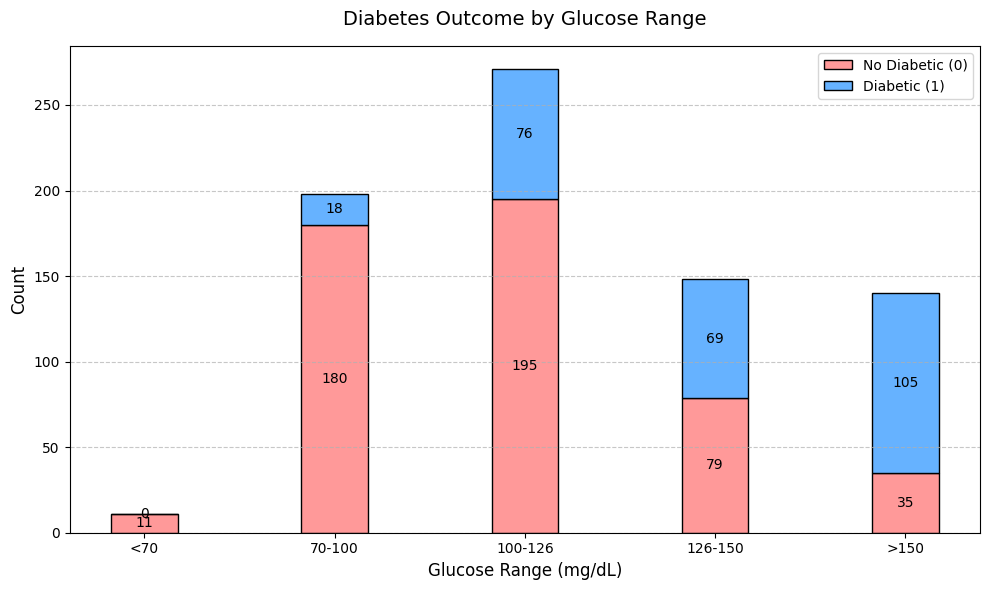

Số lượng Outcome theo khoảng Glucose:
Outcome        0    1
Glucose_Bin          
<70           11    0
70-100       180   18
100-126      195   76
126-150       79   69
>150          35  105


In [ ]:
# Chia Glucose thành các khoảng
bins = [0, 70, 100, 126, 150, 200]
labels = ['<70', '70-100', '100-126', '126-150', '>150']
df['Glucose_Bin'] = pd.cut(df['Glucose'], bins=bins, labels=labels, include_lowest=True)

# Tính số lượng Outcome trong mỗi khoảng
outcome_counts = df.groupby('Glucose_Bin', observed=True)['Outcome'].value_counts().unstack(fill_value=0)
outcome_counts = outcome_counts.reindex(labels)

# Vẽ biểu đồ cột lồng nhau
plt.figure(figsize=(10, 6))
bar_width = 0.35
x = np.arange(len(outcome_counts.index))

plt.bar(x, outcome_counts[0], bar_width, label='No Diabetic (0)', color='#FF9999', edgecolor='black')
plt.bar(x, outcome_counts[1], bar_width, bottom=outcome_counts[0], label='Diabetic (1)', color='#66B2FF', edgecolor='black')

plt.xlabel('Glucose Range (mg/dL)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Diabetes Outcome by Glucose Range', fontsize=14, pad=15)
plt.xticks(x, outcome_counts.index, rotation=0, fontsize=10)
plt.legend(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i in range(len(x)):
    plt.text(i, outcome_counts[0].iloc[i] / 2, str(outcome_counts[0].iloc[i]), ha='center', va='center', fontsize=10, color='black')
    plt.text(i, outcome_counts[0].iloc[i] + outcome_counts[1].iloc[i] / 2, str(outcome_counts[1].iloc[i]), ha='center', va='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()

print("Số lượng Outcome theo khoảng Glucose:")
print(outcome_counts)

1. Glucose càng cao, nguy cơ mắc bệnh tiểu đường càng lớn, đặc biệt từ 126 mg/dL trở lên, tỷ lệ mắc bệnh tăng rõ rệt.

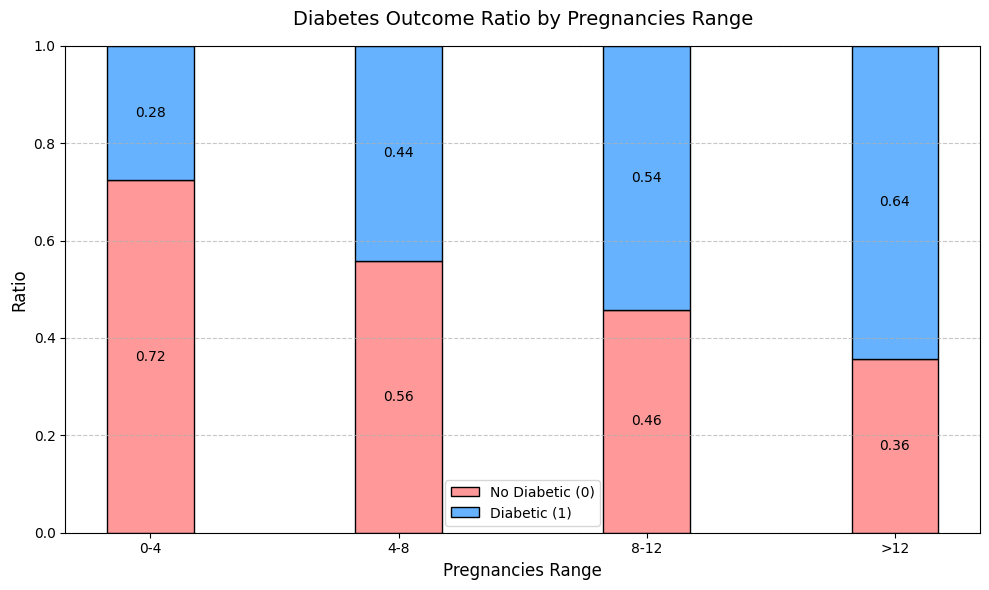

Tỷ lệ Outcome theo khoảng Pregnancies:
Outcome           Ratio_0   Ratio_1
Pregnancies_Bin                    
0-4              0.723577  0.276423
4-8              0.557895  0.442105
8-12             0.458333  0.541667
>12              0.357143  0.642857


In [ ]:
# Chia Pregnancies thành các khoảng (điều chỉnh để cân bằng)
bins = [0, 4, 8, 12, 17]  # Giảm số khoảng, mở rộng cuối
labels = ['0-4', '4-8', '8-12', '>12']
df['Pregnancies_Bin'] = pd.cut(df['Pregnancies'], bins=bins, labels=labels, include_lowest=True)

# Tính tỷ lệ Outcome trong mỗi khoảng
outcome_counts = df.groupby('Pregnancies_Bin', observed=True)['Outcome'].value_counts().unstack(fill_value=0)
outcome_counts = outcome_counts.reindex(labels)
total_counts = outcome_counts[0] + outcome_counts[1]
outcome_counts['Ratio_0'] = outcome_counts[0] / total_counts
outcome_counts['Ratio_1'] = outcome_counts[1] / total_counts

# Vẽ biểu đồ cột lồng nhau (dựa trên tỷ lệ)
plt.figure(figsize=(10, 6))
bar_width = 0.35
x = np.arange(len(outcome_counts.index))

plt.bar(x, outcome_counts['Ratio_0'], bar_width, label='No Diabetic (0)', color='#FF9999', edgecolor='black')
plt.bar(x, outcome_counts['Ratio_1'], bar_width, bottom=outcome_counts['Ratio_0'], label='Diabetic (1)', color='#66B2FF', edgecolor='black')

plt.xlabel('Pregnancies Range', fontsize=12)
plt.ylabel('Ratio', fontsize=12)
plt.title('Diabetes Outcome Ratio by Pregnancies Range', fontsize=14, pad=15)
plt.xticks(x, outcome_counts.index, rotation=0, fontsize=10)
plt.legend(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i in range(len(x)):
    plt.text(i, outcome_counts['Ratio_0'].iloc[i] / 2, f'{outcome_counts["Ratio_0"].iloc[i]:.2f}', ha='center', va='center', fontsize=10, color='black')
    plt.text(i, outcome_counts['Ratio_0'].iloc[i] + outcome_counts['Ratio_1'].iloc[i] / 2, f'{outcome_counts["Ratio_1"].iloc[i]:.2f}', ha='center', va='center', fontsize=10, color='black')

plt.ylim(0, 1)  # Giới hạn tỷ lệ từ 0 đến 1
plt.tight_layout()
plt.show()

print("Tỷ lệ Outcome theo khoảng Pregnancies:")
print(outcome_counts[['Ratio_0', 'Ratio_1']])

2. Pregnancies

Nhận xét:

Tỷ lệ Diabetic (1) có xu hướng tăng dần khi số lần mang thai tăng, đặc biệt ở khoảng 8-12 và >12. Điều này phản ánh rằng phụ nữ có nhiều lần mang thai (stress nội tiết) có nguy cơ tiểu đường cao hơn.
Khoảng 0-4 có tỷ lệ No Diabetic (0) cao, chiếm phần lớn, do đây là nhóm phổ biến trong dữ liệu.
Xu hướng: Mối quan hệ tích cực nhưng yếu, vì Pregnancies là yếu tố gián tiếp ảnh hưởng qua nội tiết.



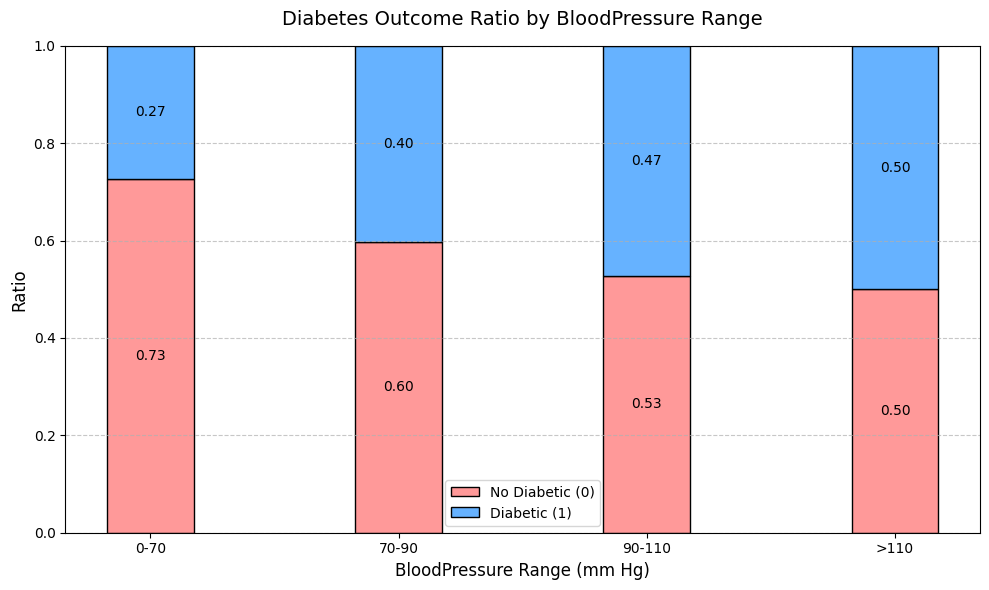

Tỷ lệ Outcome theo khoảng BloodPressure:
Outcome             Ratio_0   Ratio_1
BloodPressure_Bin                    
0-70               0.726471  0.273529
70-90              0.597436  0.402564
90-110             0.527778  0.472222
>110               0.500000  0.500000


In [ ]:
# Chia BloodPressure thành các khoảng (điều chỉnh để cân bằng)
bins = [0, 70, 90, 110, 140]  # Giảm số khoảng, hợp lý với phân bố
labels = ['0-70', '70-90', '90-110', '>110']
df['BloodPressure_Bin'] = pd.cut(df['BloodPressure'], bins=bins, labels=labels, include_lowest=True)

# Tính tỷ lệ Outcome
outcome_counts = df.groupby('BloodPressure_Bin', observed=True)['Outcome'].value_counts().unstack(fill_value=0)
outcome_counts = outcome_counts.reindex(labels)
total_counts = outcome_counts[0] + outcome_counts[1]
outcome_counts['Ratio_0'] = outcome_counts[0] / total_counts
outcome_counts['Ratio_1'] = outcome_counts[1] / total_counts

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
bar_width = 0.35
x = np.arange(len(outcome_counts.index))

plt.bar(x, outcome_counts['Ratio_0'], bar_width, label='No Diabetic (0)', color='#FF9999', edgecolor='black')
plt.bar(x, outcome_counts['Ratio_1'], bar_width, bottom=outcome_counts['Ratio_0'], label='Diabetic (1)', color='#66B2FF', edgecolor='black')

plt.xlabel('BloodPressure Range (mm Hg)', fontsize=12)
plt.ylabel('Ratio', fontsize=12)
plt.title('Diabetes Outcome Ratio by BloodPressure Range', fontsize=14, pad=15)
plt.xticks(x, outcome_counts.index, rotation=0, fontsize=10)
plt.legend(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i in range(len(x)):
    plt.text(i, outcome_counts['Ratio_0'].iloc[i] / 2, f'{outcome_counts["Ratio_0"].iloc[i]:.2f}', ha='center', va='center', fontsize=10, color='black')
    plt.text(i, outcome_counts['Ratio_0'].iloc[i] + outcome_counts['Ratio_1'].iloc[i] / 2, f'{outcome_counts["Ratio_1"].iloc[i]:.2f}', ha='center', va='center', fontsize=10, color='black')

plt.ylim(0, 1)
plt.tight_layout()
plt.show()

print("Tỷ lệ Outcome theo khoảng BloodPressure:")
print(outcome_counts[['Ratio_0', 'Ratio_1']])

3. BloodPressure

Nhận xét:

Tỷ lệ Diabetic (1) tăng nhẹ ở khoảng 90-110 và >110, cho thấy huyết áp cao có liên quan đến nguy cơ tiểu đường (liên quan đến hội chứng chuyển hóa).
Khoảng 0-70 và 70-90 có tỷ lệ No Diabetic (0) cao, phản ánh huyết áp bình thường chiếm ưu thế trong nhóm không mắc.
Xu hướng: Mối quan hệ tích cực nhưng không mạnh, có thể do nhiều giá trị 0 ban đầu đã được impute.



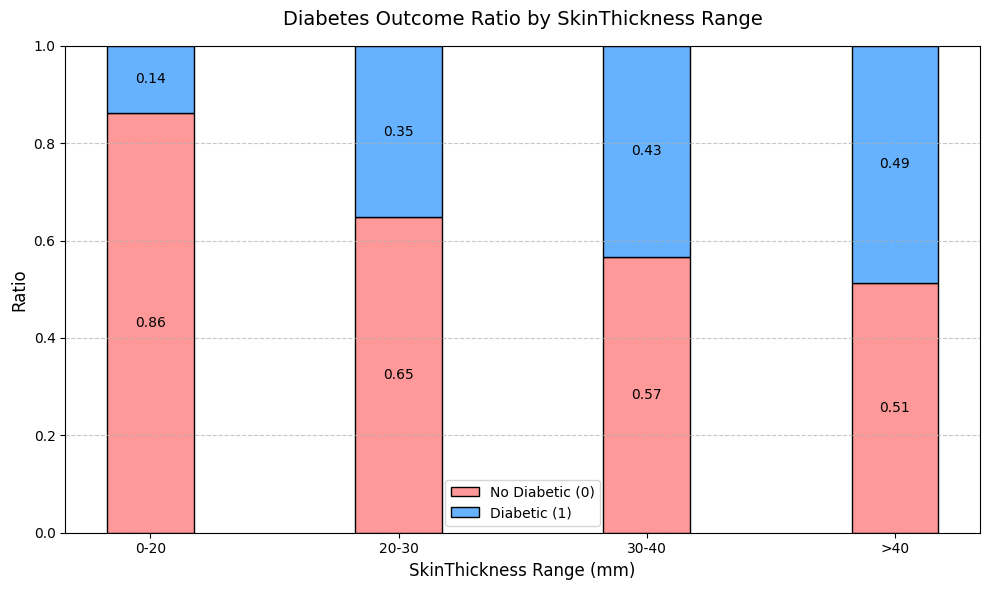

Tỷ lệ Outcome theo khoảng SkinThickness:
Outcome             Ratio_0   Ratio_1
SkinThickness_Bin                    
0-20               0.862903  0.137097
20-30              0.647783  0.352217
30-40              0.567073  0.432927
>40                0.513889  0.486111


In [ ]:
# Chia SkinThickness thành các khoảng (điều chỉnh để cân bằng)
bins = [0, 20, 30, 40, 60]  # Giảm số khoảng, hợp lý với phân bố
labels = ['0-20', '20-30', '30-40', '>40']
df['SkinThickness_Bin'] = pd.cut(df['SkinThickness'], bins=bins, labels=labels, include_lowest=True)

# Tính tỷ lệ Outcome
outcome_counts = df.groupby('SkinThickness_Bin', observed=True)['Outcome'].value_counts().unstack(fill_value=0)
outcome_counts = outcome_counts.reindex(labels)
total_counts = outcome_counts[0] + outcome_counts[1]
outcome_counts['Ratio_0'] = outcome_counts[0] / total_counts
outcome_counts['Ratio_1'] = outcome_counts[1] / total_counts

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
bar_width = 0.35
x = np.arange(len(outcome_counts.index))

plt.bar(x, outcome_counts['Ratio_0'], bar_width, label='No Diabetic (0)', color='#FF9999', edgecolor='black')
plt.bar(x, outcome_counts['Ratio_1'], bar_width, bottom=outcome_counts['Ratio_0'], label='Diabetic (1)', color='#66B2FF', edgecolor='black')

plt.xlabel('SkinThickness Range (mm)', fontsize=12)
plt.ylabel('Ratio', fontsize=12)
plt.title('Diabetes Outcome Ratio by SkinThickness Range', fontsize=14, pad=15)
plt.xticks(x, outcome_counts.index, rotation=0, fontsize=10)
plt.legend(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i in range(len(x)):
    plt.text(i, outcome_counts['Ratio_0'].iloc[i] / 2, f'{outcome_counts["Ratio_0"].iloc[i]:.2f}', ha='center', va='center', fontsize=10, color='black')
    plt.text(i, outcome_counts['Ratio_0'].iloc[i] + outcome_counts['Ratio_1'].iloc[i] / 2, f'{outcome_counts["Ratio_1"].iloc[i]:.2f}', ha='center', va='center', fontsize=10, color='black')

plt.ylim(0, 1)
plt.tight_layout()
plt.show()

print("Tỷ lệ Outcome theo khoảng SkinThickness:")
print(outcome_counts[['Ratio_0', 'Ratio_1']])

4. SkinThickness

Nhận xét:

Tỷ lệ Diabetic (1) tăng dần từ khoảng 0-20 đến >40, cho thấy độ dày da (liên quan đến mỡ dưới da) có tương quan với tiểu đường, đặc biệt ở mức cao.
Khoảng 0-20 có tỷ lệ No Diabetic (0) cao, do nhiều giá trị 0 ban đầu (missing data) đã được impute về median.
Xu hướng: Mối quan hệ tích cực vừa phải, phản ánh mức độ béo phì cục bộ.




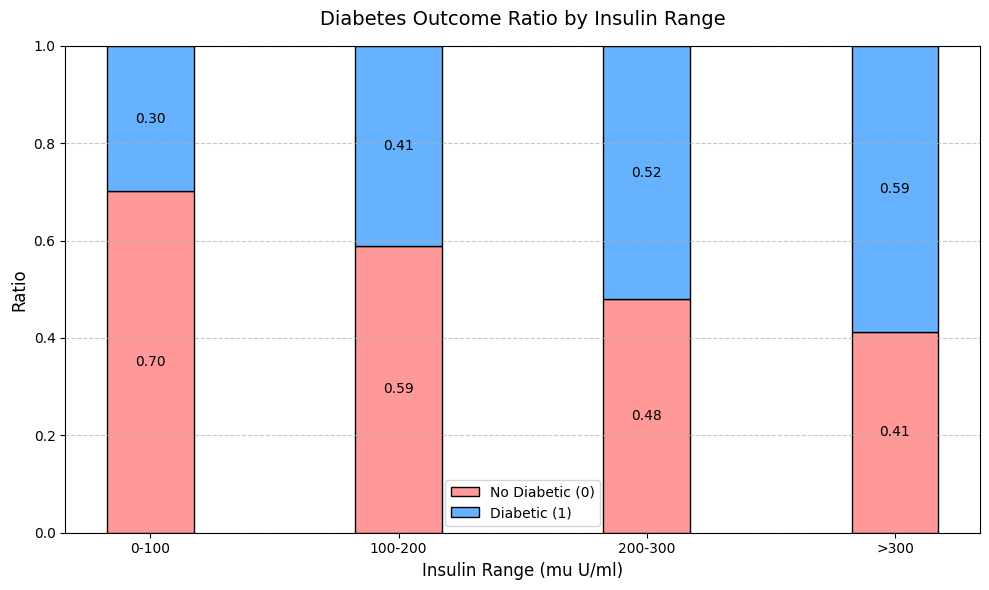

Tỷ lệ Outcome theo khoảng Insulin:
Outcome       Ratio_0   Ratio_1
Insulin_Bin                    
0-100        0.700952  0.299048
100-200      0.588608  0.411392
200-300      0.479167  0.520833
>300         0.411765  0.588235


In [ ]:
# Chia Insulin thành các khoảng (điều chỉnh để cân bằng)
bins = [0, 100, 200, 300, 600]  # Giảm số khoảng, tập trung vào phân bố chính
labels = ['0-100', '100-200', '200-300', '>300']
df['Insulin_Bin'] = pd.cut(df['Insulin'], bins=bins, labels=labels, include_lowest=True)

# Tính tỷ lệ Outcome
outcome_counts = df.groupby('Insulin_Bin', observed=True)['Outcome'].value_counts().unstack(fill_value=0)
outcome_counts = outcome_counts.reindex(labels)
total_counts = outcome_counts[0] + outcome_counts[1]
outcome_counts['Ratio_0'] = outcome_counts[0] / total_counts
outcome_counts['Ratio_1'] = outcome_counts[1] / total_counts

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
bar_width = 0.35
x = np.arange(len(outcome_counts.index))

plt.bar(x, outcome_counts['Ratio_0'], bar_width, label='No Diabetic (0)', color='#FF9999', edgecolor='black')
plt.bar(x, outcome_counts['Ratio_1'], bar_width, bottom=outcome_counts['Ratio_0'], label='Diabetic (1)', color='#66B2FF', edgecolor='black')

plt.xlabel('Insulin Range (mu U/ml)', fontsize=12)
plt.ylabel('Ratio', fontsize=12)
plt.title('Diabetes Outcome Ratio by Insulin Range', fontsize=14, pad=15)
plt.xticks(x, outcome_counts.index, rotation=0, fontsize=10)
plt.legend(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i in range(len(x)):
    plt.text(i, outcome_counts['Ratio_0'].iloc[i] / 2, f'{outcome_counts["Ratio_0"].iloc[i]:.2f}', ha='center', va='center', fontsize=10, color='black')
    plt.text(i, outcome_counts['Ratio_0'].iloc[i] + outcome_counts['Ratio_1'].iloc[i] / 2, f'{outcome_counts["Ratio_1"].iloc[i]:.2f}', ha='center', va='center', fontsize=10, color='black')

plt.ylim(0, 1)
plt.tight_layout()
plt.show()

print("Tỷ lệ Outcome theo khoảng Insulin:")
print(outcome_counts[['Ratio_0', 'Ratio_1']])

5. Insulin

Nhận xét:

Tỷ lệ Diabetic (1) tăng đáng kể ở khoảng 200-300 và >300, cho thấy mức insulin cao (đề kháng insulin) liên quan chặt chẽ với tiểu đường.
Khoảng 0-100 có tỷ lệ No Diabetic (0) cao, do nhiều giá trị 0 ban đầu (missing data) đã được impute, làm giảm độ nhạy của feature này.
Xu hướng: Mối quan hệ tích cực mạnh, nhưng bị ảnh hưởng bởi dữ liệu thiếu.



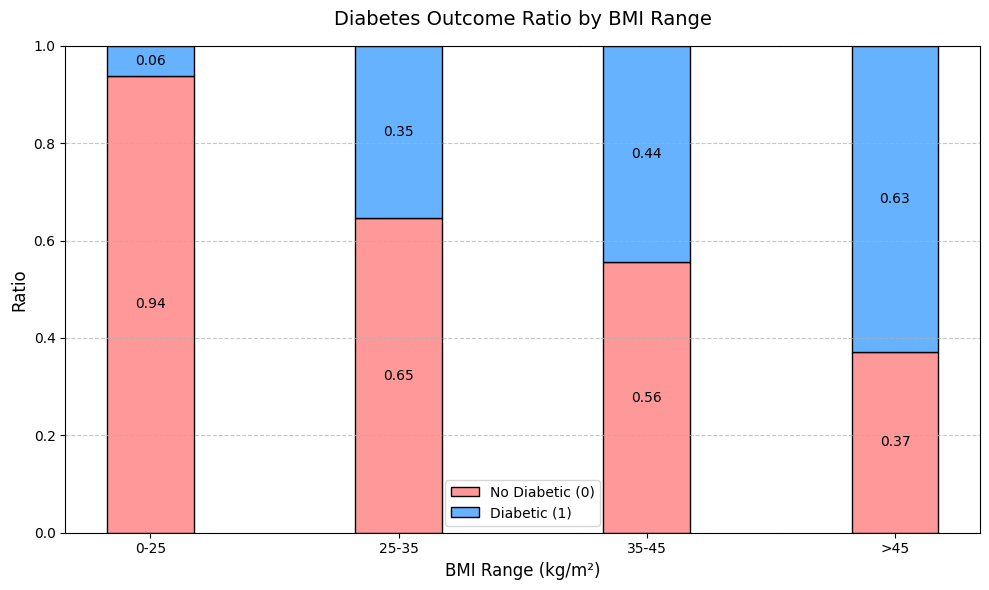

Tỷ lệ Outcome theo khoảng BMI:
Outcome   Ratio_0   Ratio_1
BMI_Bin                    
0-25     0.937500  0.062500
25-35    0.645631  0.354369
35-45    0.555024  0.444976
>45      0.371429  0.628571


In [ ]:
# Chia BMI thành các khoảng (điều chỉnh để cân bằng)
bins = [0, 25, 35, 45, 70]  # Giảm số khoảng, mở rộng cuối
labels = ['0-25', '25-35', '35-45', '>45']
df['BMI_Bin'] = pd.cut(df['BMI'], bins=bins, labels=labels, include_lowest=True)

# Tính tỷ lệ Outcome
outcome_counts = df.groupby('BMI_Bin', observed=True)['Outcome'].value_counts().unstack(fill_value=0)
outcome_counts = outcome_counts.reindex(labels)
total_counts = outcome_counts[0] + outcome_counts[1]
outcome_counts['Ratio_0'] = outcome_counts[0] / total_counts
outcome_counts['Ratio_1'] = outcome_counts[1] / total_counts

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
bar_width = 0.35
x = np.arange(len(outcome_counts.index))

plt.bar(x, outcome_counts['Ratio_0'], bar_width, label='No Diabetic (0)', color='#FF9999', edgecolor='black')
plt.bar(x, outcome_counts['Ratio_1'], bar_width, bottom=outcome_counts['Ratio_0'], label='Diabetic (1)', color='#66B2FF', edgecolor='black')

plt.xlabel('BMI Range (kg/m²)', fontsize=12)
plt.ylabel('Ratio', fontsize=12)
plt.title('Diabetes Outcome Ratio by BMI Range', fontsize=14, pad=15)
plt.xticks(x, outcome_counts.index, rotation=0, fontsize=10)
plt.legend(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i in range(len(x)):
    plt.text(i, outcome_counts['Ratio_0'].iloc[i] / 2, f'{outcome_counts["Ratio_0"].iloc[i]:.2f}', ha='center', va='center', fontsize=10, color='black')
    plt.text(i, outcome_counts['Ratio_0'].iloc[i] + outcome_counts['Ratio_1'].iloc[i] / 2, f'{outcome_counts["Ratio_1"].iloc[i]:.2f}', ha='center', va='center', fontsize=10, color='black')

plt.ylim(0, 1)
plt.tight_layout()
plt.show()

print("Tỷ lệ Outcome theo khoảng BMI:")
print(outcome_counts[['Ratio_0', 'Ratio_1']])

6. BMI

Nhận xét:

Tỷ lệ Diabetic (1) tăng rõ rệt ở khoảng 35-45 và >45, chỉ ra rằng béo phì (BMI cao) là yếu tố nguy cơ lớn của tiểu đường.
Khoảng 0-25 có tỷ lệ No Diabetic (0) cao, phản ánh nhóm cân nặng bình thường chiếm ưu thế.
Xu hướng: Mối quan hệ tích cực mạnh, phù hợp với y học (béo phì là yếu tố chính của tiểu đường type 2).



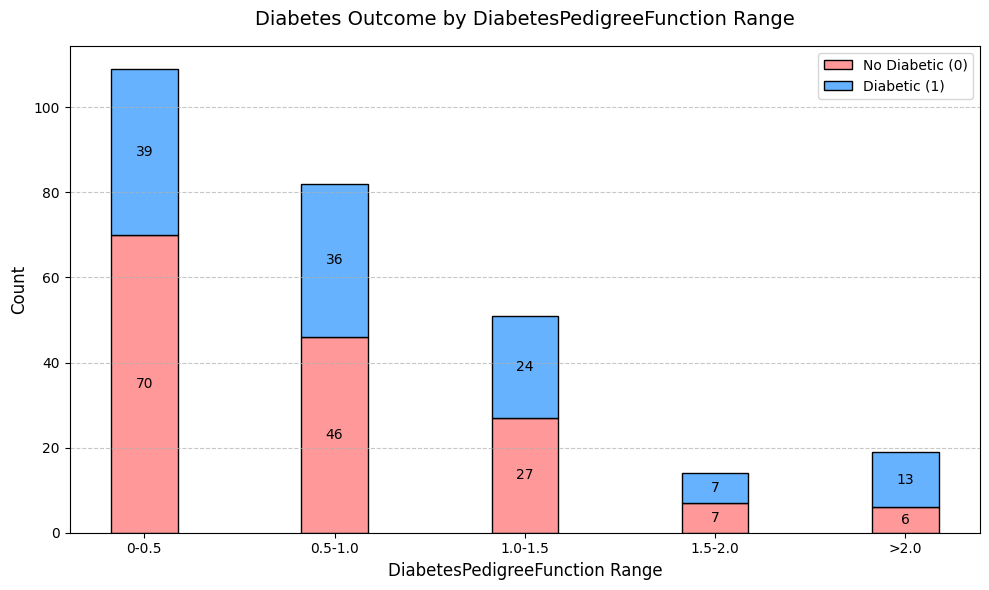

Số lượng Outcome theo khoảng DiabetesPedigreeFunction:
Outcome                        0   1
DiabetesPedigreeFunction_Bin        
0-0.5                         70  39
0.5-1.0                       46  36
1.0-1.5                       27  24
1.5-2.0                        7   7
>2.0                           6  13


In [ ]:
# Chia DiabetesPedigreeFunction thành các khoảng
bins = [0, 0.5, 1.0, 1.5, 2.0, 2.5]
labels = ['0-0.5', '0.5-1.0', '1.0-1.5', '1.5-2.0', '>2.0']
df['DiabetesPedigreeFunction_Bin'] = pd.cut(df['DiabetesPedigreeFunction'], bins=bins, labels=labels, include_lowest=True)

# Tính số lượng Outcome
outcome_counts = df.groupby('DiabetesPedigreeFunction_Bin', observed=True)['Outcome'].value_counts().unstack(fill_value=0)
outcome_counts = outcome_counts.reindex(labels)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
bar_width = 0.35
x = np.arange(len(outcome_counts.index))

plt.bar(x, outcome_counts[0], bar_width, label='No Diabetic (0)', color='#FF9999', edgecolor='black')
plt.bar(x, outcome_counts[1], bar_width, bottom=outcome_counts[0], label='Diabetic (1)', color='#66B2FF', edgecolor='black')

plt.xlabel('DiabetesPedigreeFunction Range', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Diabetes Outcome by DiabetesPedigreeFunction Range', fontsize=14, pad=15)
plt.xticks(x, outcome_counts.index, rotation=0, fontsize=10)
plt.legend(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i in range(len(x)):
    plt.text(i, outcome_counts[0].iloc[i] / 2, str(outcome_counts[0].iloc[i]), ha='center', va='center', fontsize=10, color='black')
    plt.text(i, outcome_counts[0].iloc[i] + outcome_counts[1].iloc[i] / 2, str(outcome_counts[1].iloc[i]), ha='center', va='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()

print("Số lượng Outcome theo khoảng DiabetesPedigreeFunction:")
print(outcome_counts)

7. DiabetesPedigreeFunction

Nhận xét:

Tỷ lệ Diabetic (1) có xu hướng tăng khi giá trị DiabetesPedigreeFunction tăng, đặc biệt ở khoảng 1.0-1.5 và >2.0. Điều này phản ánh rằng tiền sử gia đình tiểu đường (nguy cơ di truyền) có ảnh hưởng đáng kể đến nguy cơ mắc bệnh.
Khoảng 0-0.5 có tỷ lệ No Diabetic (0) cao, do đây là nhóm có nguy cơ di truyền thấp, chiếm phần lớn trong dữ liệu.
Xu hướng: Mối quan hệ tích cực và khá mạnh, vì feature này đo lường yếu tố di truyền trực tiếp liên quan đến tiểu đường type 2.

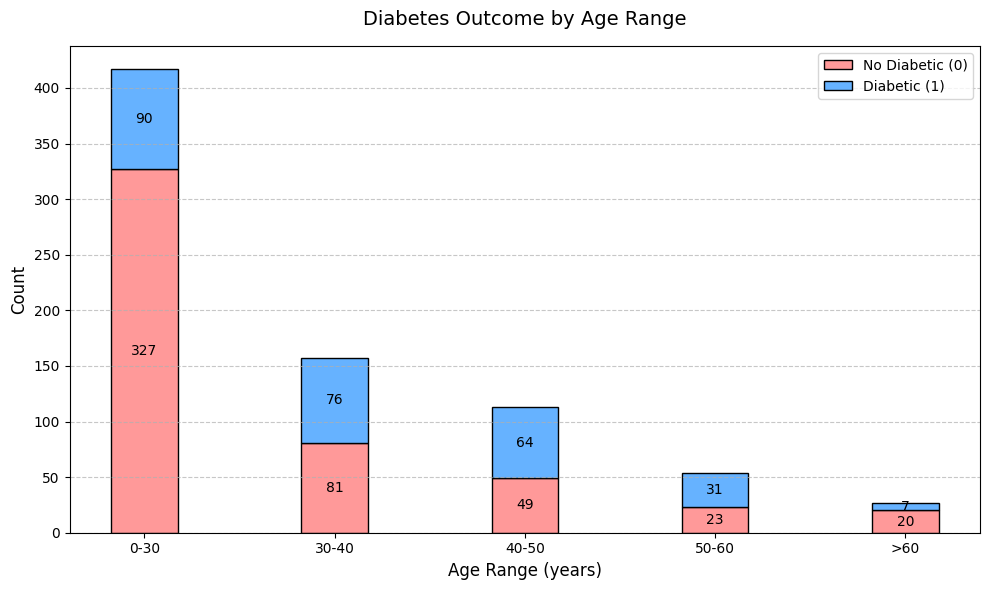

Số lượng Outcome theo khoảng Age:
Outcome    0   1
Age_Bin         
0-30     327  90
30-40     81  76
40-50     49  64
50-60     23  31
>60       20   7


In [ ]:
# Chia Age thành các khoảng
bins = [0, 30, 40, 50, 60, 90]
labels = ['0-30', '30-40', '40-50', '50-60', '>60']
df['Age_Bin'] = pd.cut(df['Age'], bins=bins, labels=labels, include_lowest=True)

# Tính số lượng Outcome
outcome_counts = df.groupby('Age_Bin', observed=True)['Outcome'].value_counts().unstack(fill_value=0)
outcome_counts = outcome_counts.reindex(labels)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
bar_width = 0.35
x = np.arange(len(outcome_counts.index))

plt.bar(x, outcome_counts[0], bar_width, label='No Diabetic (0)', color='#FF9999', edgecolor='black')
plt.bar(x, outcome_counts[1], bar_width, bottom=outcome_counts[0], label='Diabetic (1)', color='#66B2FF', edgecolor='black')

plt.xlabel('Age Range (years)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Diabetes Outcome by Age Range', fontsize=14, pad=15)
plt.xticks(x, outcome_counts.index, rotation=0, fontsize=10)
plt.legend(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i in range(len(x)):
    plt.text(i, outcome_counts[0].iloc[i] / 2, str(outcome_counts[0].iloc[i]), ha='center', va='center', fontsize=10, color='black')
    plt.text(i, outcome_counts[0].iloc[i] + outcome_counts[1].iloc[i] / 2, str(outcome_counts[1].iloc[i]), ha='center', va='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()

print("Số lượng Outcome theo khoảng Age:")
print(outcome_counts)

8. Age

Nhận xét:

Tỷ lệ Diabetic (1) tăng dần khi tuổi tăng, đặc biệt ở khoảng 50-60 và >60, cho thấy tuổi cao là yếu tố nguy cơ rõ rệt của tiểu đường (liên quan đến giảm chức năng tuyến tụy và đề kháng insulin).
Khoảng 0-30 và 30-40 có tỷ lệ No Diabetic (0) cao, phản ánh nhóm trẻ tuổi ít mắc bệnh hơn.
Xu hướng: Mối quan hệ tích cực và mạnh, phù hợp với y học (nguy cơ tiểu đường tăng theo tuổi).

## KẾT THÚC

In [10]:
!jupyter nbconvert --to html "eda.ipynb"

[NbConvertApp] Converting notebook eda.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 8 image(s).
[NbConvertApp] Writing 795972 bytes to eda.html
